# Mask R-CNN – Clothing Instance Segmentation

In [1]:
!pip install pycocotools -q

import os
import ast
import numpy as np
import pandas as pd
import cv2
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, f1_score, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/train_annotations.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/val_annotations.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/test_annotations.csv")

print("Train:", len(train_df))
print("Val:",   len(val_df))
print("Test:",  len(test_df))
train_df.head()

Train: 39241
Val: 8386
Test: 8453


,image,category,bbox,segmentation
0,161364.jpg,trousers,"[252, 323, 522, 639]","[[432, 324, 339, 353, 250, 393, 290, 532, 346,..."
1,161364.jpg,short sleeve top,"[30, 1, 466, 481]","[[183, 5, 175, 19, 157, 35, 125, 48, 92, 51, 8..."
2,117178.jpg,trousers,"[159, 423, 337, 701]","[[328, 432, 249, 432, 162, 430, 164, 540, 164,..."
3,131919.jpg,trousers,"[158, 381, 366, 650]","[[346, 450, 263, 438, 227, 388, 203, 451, 186,..."
4,131919.jpg,short sleeve top,"[212, 140, 481, 492]","[[429, 214, 407, 230, 378, 229, 354, 210, 353,..."


In [3]:
# group labels per image
train_group = train_df.groupby("image")["category"].apply(list).reset_index()
val_group   = val_df.groupby("image")["category"].apply(list).reset_index()
test_group  = test_df.groupby("image")["category"].apply(list).reset_index()

train_group.head()

,image,category
0,000014.jpg,"[skirt, long sleeve top]"
1,000015.jpg,[long sleeve top]
2,000018.jpg,"[trousers, long sleeve top]"
3,000026.jpg,"[skirt, short sleeve top]"
4,000027.jpg,"[skirt, short sleeve top]"


In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
mlb.fit(train_group["category"])

print(mlb.classes_)

['long sleeve top' 'short sleeve top' 'shorts' 'skirt' 'trousers']


In [5]:
# ── Image transforms ──────────────────────────────────────────────────────────
# NO Normalize: MaskRCNN's GeneralizedRCNNTransform normalizes internally.
#   Adding it here causes double-normalization which corrupts pixel values.
# NO spatial augmentations (flip/crop) here: applied to image only, not mask,
#   causing misaligned labels. Joint augmentation is done in __getitem__.
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

IMG_SIZE = 224


In [6]:
# Mask R-CNN: background = 0, clothing classes start from 1
class_to_idx = {cls: i + 1 for i, cls in enumerate(mlb.classes_)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

print(class_to_idx)


def build_image_lookup(df):
    """Build a dict: image_filename -> list of annotation dicts."""
    lookup = {}
    for _, row in df.iterrows():
        fname = row["image"]
        if fname not in lookup:
            lookup[fname] = []
        try:
            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            seg  = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"], str) else row["segmentation"]
        except Exception:
            bbox, seg = [], []
        lookup[fname].append({"bbox": bbox, "seg": seg, "category": row["category"]})
    return lookup


train_lookup = build_image_lookup(train_df)
val_lookup   = build_image_lookup(val_df)
test_lookup  = build_image_lookup(test_df)

{'long sleeve top': 1, 'short sleeve top': 2, 'shorts': 3, 'skirt': 4, 'trousers': 5}


In [7]:
import random
import torchvision.transforms.functional as TF

from torchvision.transforms.functional import to_tensor
class FashionDataset(Dataset):

    def __init__(self, group_df, img_dir, lookup, transform=None):
        self.group_df  = group_df
        self.img_dir   = img_dir
        self.lookup    = lookup
        self.transform = transform

    def __len__(self):
        return len(self.group_df)

    def __getitem__(self, idx):
        fname    = self.group_df.iloc[idx]["image"]
        img_path = os.path.join(self.img_dir, fname)
        image    = Image.open(img_path).convert("RGB")
        W, H     = image.size   # original dimensions before any transform

        anns = self.lookup.get(fname, [])
        boxes, labels, masks = [], [], []

        for ann in anns:
            cat  = ann["category"]
            bbox = ann["bbox"]
            seg  = ann["seg"]

            if cat not in class_to_idx or len(bbox) != 4:
                continue

            x1, y1, x2, y2 = float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])

            # Clamp to original image boundaries
            x1 = max(0.0, min(x1, W))
            y1 = max(0.0, min(y1, H))
            x2 = max(0.0, min(x2, W))
            y2 = max(0.0, min(y2, H))

            if x2 - x1 <= 0 or y2 - y1 <= 0:
                continue

            # ── Fix 1: scale bbox to match the resized image (224x224) ────────
            scale_x = IMG_SIZE / W
            scale_y = IMG_SIZE / H
            x1, x2 = x1 * scale_x, x2 * scale_x
            y1, y2 = y1 * scale_y, y2 * scale_y

            # ── Fix 2: build mask at original size, draw ALL polygons, ─────────
            #           then resize to 224x224
            mask = np.zeros((H, W), dtype=np.uint8)
            if seg:
                for poly in seg:
                    # each poly may be a flat list [x1,y1,x2,y2,...]
                    poly_np = np.array(poly).reshape(-1, 2).astype(np.int32)
                    cv2.fillPoly(mask, [poly_np], 1)
            # fallback: use bbox if polygon produced empty mask
            if mask.sum() == 0:
                orig_x1 = int(float(bbox[0])); orig_y1 = int(float(bbox[1]))
                orig_x2 = int(float(bbox[2])); orig_y2 = int(float(bbox[3]))
                mask[orig_y1:orig_y2, orig_x1:orig_x2] = 1

            # Resize mask to match the image size passed to the model
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

            boxes.append([x1, y1, x2, y2])
            labels.append(class_to_idx[cat])
            masks.append(mask)

        # ── Joint horizontal flip (train only) ──────────────────────────
        # Same random state applied to image AND all masks AND boxes.
        if self.transform is not None and random.random() > 0.5 and len(boxes) > 0:
            image = TF.hflip(image)
            masks = [np.fliplr(m).copy() for m in masks]
            boxes = [[IMG_SIZE - b[2], b[1], IMG_SIZE - b[0], b[3]] for b in boxes]

        if len(boxes) == 0:
            boxes   = torch.zeros((0, 4),              dtype=torch.float32)
            labels  = torch.zeros((0,),                dtype=torch.int64)
            masks   = torch.zeros((0, IMG_SIZE, IMG_SIZE), dtype=torch.uint8)
            area    = torch.zeros((0,),                dtype=torch.float32)
            iscrowd = torch.zeros((0,),                dtype=torch.uint8)
        else:
            boxes   = torch.as_tensor(boxes,            dtype=torch.float32)
            labels  = torch.as_tensor(labels,           dtype=torch.int64)
            masks   = torch.as_tensor(np.stack(masks),  dtype=torch.uint8)
            area    = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),),        dtype=torch.uint8)

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "masks":    masks,
            "image_id": torch.tensor([idx]),
            "area":     area,
            "iscrowd":  iscrowd,
        }

        if self.transform:
            image = self.transform(image)   # [3, 224, 224]
        else:
            image = to_tensor(image)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

img_dir = "/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/sample_35k/sample_35k/images"

train_dataset = FashionDataset(train_group, img_dir, train_lookup, train_tf)
val_dataset   = FashionDataset(val_group,   img_dir, val_lookup,   val_tf)
test_dataset  = FashionDataset(test_group,  img_dir, test_lookup,  val_tf)

print("Train:", len(train_dataset))
print("Val:",   len(val_dataset))
print("Test:",  len(test_dataset))

# ── WeightedRandomSampler: oversample images containing rare classes ──────────
class_counts = Counter()
for fname in train_group["image"]:
    for ann in train_lookup.get(fname, []):
        if ann["category"] in class_to_idx:
            class_counts[ann["category"]] += 1

total_inst = sum(class_counts.values())
inv_freq   = {c: total_inst / max(class_counts[c], 1) for c in class_counts}
mean_w     = sum(inv_freq.values()) / len(inv_freq)
inv_freq   = {c: v / mean_w for c, v in inv_freq.items()}  # normalize mean=1

print("\nClass instance counts and sampling weights:")
for cls in sorted(class_counts):
    print(f"  {cls:<22}: count={class_counts[cls]:5d}  weight={inv_freq[cls]:.3f}")

sample_weights = []
for fname in train_group["image"]:
    cats = [a["category"] for a in train_lookup.get(fname, [])
            if a["category"] in class_to_idx]
    w = max((inv_freq.get(c, 1.0) for c in cats), default=1.0)
    sample_weights.append(w)

BATCH_SIZE      = 4
STEPS_PER_EPOCH = 1500
NUM_SAMPLES     = BATCH_SIZE * STEPS_PER_EPOCH
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=NUM_SAMPLES,
    replacement=True
)

# ── Larger batch size: 2→4 for better GPU utilisation on T4×2 ──────────────
# num_workers 2→1 + persistent_workers avoids repeated worker spawning overhead
train_loader = DataLoader(train_dataset, batch_size=4, sampler=sampler,
                          collate_fn=collate_fn, num_workers=1, pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          collate_fn=collate_fn, num_workers=1, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False,
                          collate_fn=collate_fn, num_workers=1, pin_memory=True,
                          persistent_workers=True)
print(f"Train loader: {len(train_loader)} steps/epoch  (capped at {STEPS_PER_EPOCH}, batch={BATCH_SIZE})")
print(f"Val   loader: {len(val_loader)} steps/epoch")
images, targets = next(iter(train_loader))
print(images[0].shape)
print("boxes:", targets[0]["boxes"].shape)
print("masks:", targets[0]["masks"].shape)


Train: 24500
Val: 5250
Test: 5250

Class instance counts and sampling weights:
  long sleeve top       : count= 6094  weight=1.172
  short sleeve top      : count=12217  weight=0.584
  shorts                : count= 6222  weight=1.148
  skirt                 : count= 5360  weight=1.332
  trousers              : count= 9348  weight=0.764

WeightedRandomSampler ready — 24500 images
torch.Size([3, 224, 224])
boxes: torch.Size([2, 4])
masks: torch.Size([2, 224, 224])


# Mask R-CNN

In [9]:
import torch.nn.functional as F

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        return loss.sum()

In [10]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn

num_classes = len(mlb.classes_) + 1  # + background

model = maskrcnn_resnet50_fpn(weights="DEFAULT")

# Replace box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, num_classes
    )

# Replace mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = \
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask, 256, num_classes
    )

model.to(device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 210MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [11]:
import torch.nn.functional as F
import torchvision.models.detection.roi_heads as _roi_heads_mod

focal_loss_fn = FocalLoss()

def fastrcnn_loss_focal(class_logits, box_regression, labels, regression_targets):
    labels_cat      = torch.cat(labels,             dim=0)
    reg_targets_cat = torch.cat(regression_targets, dim=0)

    # Classification loss with FocalLoss
    classification_loss = focal_loss_fn(class_logits, labels_cat)

    # Box regression: correct class slice only for positives
    N           = class_logits.shape[0]
    num_classes = class_logits.shape[1]
    box_regression = box_regression.reshape(N, num_classes, 4)

    pos_inds   = torch.where(labels_cat > 0)[0]
    pos_labels = labels_cat[pos_inds]

    if pos_inds.numel() > 0:
        box_loss = F.smooth_l1_loss(
            box_regression[pos_inds, pos_labels],
            reg_targets_cat[pos_inds],
            beta=1.0 / 9,
            reduction="sum",
        ) / labels_cat.numel()
    else:
        box_loss = box_regression.sum() * 0.0

    return classification_loss, box_loss

# Patch at MODULE level — instance assignment is silently ignored by RoIHeads
_roi_heads_mod.fastrcnn_loss = fastrcnn_loss_focal
print("fastrcnn_loss patched at module level with FocalLoss.")


fastrcnn_loss patched at module level with FocalLoss.


In [12]:
for param in model.backbone.parameters():
    param.requires_grad = False

In [13]:
# Phase 1: only train non-frozen params (backbone frozen in cell 13)
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

# ── AMP (Mixed Precision): ~40% speedup on T4 GPUs ───────────────────────
from torch.cuda.amp import GradScaler
scaler = GradScaler()


/tmp/ipykernel_24/2583131990.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [14]:
num_epochs    = 10
freeze_epochs = 5

train_losses  = []
val_losses    = []
best_val_loss = float("inf")

for epoch in range(num_epochs):

    # ── Phase 2: unfreeze backbone ────────────────────────────────────────────
    if epoch == freeze_epochs:
        print("Unfreezing backbone...")
        for param in model.backbone.parameters():
            param.requires_grad = True
        # Must recreate optimizer AND scheduler after unfreezing
        optimizer = optim.SGD(
            model.parameters(),
            lr=0.0005, momentum=0.9, weight_decay=0.0005
        )
        lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=3, gamma=0.1
        )
        scaler = GradScaler()  # reset scaler for phase 2
        print(f"  New LR: {optimizer.param_groups[0]['lr']}")

    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for images, targets in train_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():   # AMP: forward in float16
            loss_dict = model(images, targets)
            loss      = sum(loss_dict.values())
        scaler.scale(loss).backward()     # scaled backward
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)            # unscaled param update
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ── Validation every 2 epochs (~30% time saving) ─────────────────────────
    if (epoch + 1) % 2 == 0 or epoch == num_epochs - 1:
        model.train()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images  = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                with torch.cuda.amp.autocast():  # AMP in val too
                    val_loss += sum(model(images, targets).values()).item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        print(f"  [Val] loss: {val_loss:.4f}")
    else:
        # Reuse last known val loss on skipped epochs
        val_loss = val_losses[-1] if val_losses else float('inf')
        val_losses.append(val_loss)
        print(f"  [Val] skipped (using last: {val_loss:.4f})")

    # ── Save best checkpoint ──────────────────────────────────────────────────
    saved = val_loss < best_val_loss
    if saved:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_maskrcnn.pth")

    lr_scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}"
          f"{'  checkmark saved' if saved else ''}")

model.load_state_dict(
    torch.load("best_maskrcnn.pth", map_location=device, weights_only=True)
)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


/tmp/ipykernel_24/2981826639.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # AMP: forward in float16


  [Val] skipped (using last: inf)
Epoch [01/10] Train: 0.3953 | Val: inf | LR: 0.005000


/tmp/ipykernel_24/2981826639.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # AMP in val too


  [Val] loss: 0.3348
Epoch [02/10] Train: 0.3461 | Val: 0.3348 | LR: 0.005000  checkmark saved
  [Val] skipped (using last: 0.3348)
Epoch [03/10] Train: 0.3342 | Val: 0.3348 | LR: 0.005000
  [Val] loss: 0.3298
Epoch [04/10] Train: 0.3281 | Val: 0.3298 | LR: 0.005000  checkmark saved
  [Val] skipped (using last: 0.3298)
Epoch [05/10] Train: 0.3231 | Val: 0.3298 | LR: 0.000500
Unfreezing backbone...
  New LR: 0.0005


/tmp/ipykernel_24/2981826639.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # reset scaler for phase 2


  [Val] loss: 0.2704
Epoch [06/10] Train: 0.2815 | Val: 0.2704 | LR: 0.000500  checkmark saved
  [Val] skipped (using last: 0.2704)
Epoch [07/10] Train: 0.2595 | Val: 0.2704 | LR: 0.000500
  [Val] loss: 0.2547
Epoch [08/10] Train: 0.2482 | Val: 0.2547 | LR: 0.000050  checkmark saved
  [Val] skipped (using last: 0.2547)
Epoch [09/10] Train: 0.2388 | Val: 0.2547 | LR: 0.000050
  [Val] loss: 0.2470
Epoch [10/10] Train: 0.2368 | Val: 0.2470 | LR: 0.000050  checkmark saved

Training complete. Best val loss: 0.2470


In [15]:
raw_results = []

model.eval()

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            raw_results.append((
                {
                    "boxes": out["boxes"].cpu().numpy(),
                    "labels": out["labels"].cpu().numpy(),
                    "scores": out["scores"].cpu().numpy(),
                    "masks": out["masks"].cpu().numpy()
                },
                {
                    "boxes": tgt["boxes"].cpu().numpy(),
                    "labels": tgt["labels"].cpu().numpy(),
                    "masks": tgt["masks"].cpu().numpy()
                }
            ))

In [16]:
import json
from pycocotools import mask as mask_utils

coco_gt = {"images": [], "annotations": [], "categories": []}

for i, cls in enumerate(mlb.classes_):
    coco_gt["categories"].append({"id": i + 1, "name": cls})

ann_id = 1

for img_id, (out, tgt) in enumerate(raw_results):
    coco_gt["images"].append({
        "id": img_id, "height": IMG_SIZE, "width": IMG_SIZE
    })

    boxes  = tgt["boxes"]
    labels = tgt["labels"]
    masks  = tgt["masks"]   # (N, H, W)

    for box, label, mask in zip(boxes, labels, masks):
        x1, y1, x2, y2 = box
        w_box = float(x2 - x1)
        h_box = float(y2 - y1)

        m = mask.astype(np.uint8)
        if m.ndim == 3:
            m = m[0]
        rle = mask_utils.encode(np.asfortranarray(m))
        rle["counts"] = rle["counts"].decode("utf-8")

        coco_gt["annotations"].append({
            "id":           ann_id,
            "image_id":     img_id,
            "category_id":  int(label),
            "bbox":         [float(x1), float(y1), w_box, h_box],
            "area":         w_box * h_box,
            "segmentation": rle,
            "iscrowd":      0,
        })
        ann_id += 1

with open("/kaggle/working/gt.json", "w") as f:
    json.dump(coco_gt, f)

print("gt.json created with", len(coco_gt["annotations"]), "annotations")


gt.json created with 8386 annotations


In [17]:
coco_pred = []

for img_id, (out, tgt) in enumerate(raw_results):
    boxes = out["boxes"]
    labels = out["labels"]
    scores = out["scores"]

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box

        coco_pred.append({
            "image_id": img_id,
            "category_id": int(label),
            "bbox": [
                float(x1),
                float(y1),
                float(x2 - x1),
                float(y2 - y1)
            ],
            "score": float(score)
        })

with open("/kaggle/working/pred.json", "w") as f:
    json.dump(coco_pred, f)

print(" pred.json created")

 pred.json created


In [18]:
with open("/kaggle/working/gt.json") as f:
    gt = json.load(f)

with open("/kaggle/working/pred.json") as f:
    pred = json.load(f)

print("GT images:", len(gt["images"]))
print("GT annotations:", len(gt["annotations"]))
print("Predictions:", len(pred))

GT images: 5250
GT annotations: 8386
Predictions: 91549


In [19]:
# pycocotools installed in cell 1 — nothing to do here.


In [20]:
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

cocoGt = COCO("/kaggle/working/gt.json")

# Guard: loadRes raises AssertionError if prediction list is empty
with open("/kaggle/working/pred.json") as _f:
    _pred_list = json.load(_f)

if not _pred_list:
    print("WARNING: No predictions found — skipping mAP evaluation.")
    precision     = None
    recall        = None
    map50_95_bbox = 0.0
    map50_bbox    = 0.0
    map75_bbox    = 0.0
else:
    cocoDt = cocoGt.loadRes("/kaggle/working/pred.json")

    cocoEval = COCOeval(cocoGt, cocoDt, iouType='bbox')
    cocoEval.evaluate()
    cocoEval.accumulate()
    cocoEval.summarize()

    # precision shape: [iou_thresholds, recall_thresholds, classes, area_ranges, max_dets]
    #                  [      10,               101,        num_cls,      4,          3   ]
    # -1 = recall threshold never reached
    precision = cocoEval.eval['precision']
    recall    = cocoEval.eval['recall']

    # cocoEval.stats: 0=AP@[.5:.95]  1=AP@.50  2=AP@.75  ...
    map50_95_bbox = float(cocoEval.stats[0])
    map50_bbox    = float(cocoEval.stats[1])
    map75_bbox    = float(cocoEval.stats[2])

    print(f"\nmAP@[0.5:0.95] = {map50_95_bbox:.4f}")
    print(f"mAP@0.50       = {map50_bbox:.4f}")
    print(f"mAP@0.75       = {map75_bbox:.4f}")
    print(f"\nprecision array shape: {precision.shape}")


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.89s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.22s).
Accumulating evaluation results...
DONE (t=2.16s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.560
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.770
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.654
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.379
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.549
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.586
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.760
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.784
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [21]:
import numpy as np

if precision is None:
    print("No predictions available — skipping F1 computation.")
    f1_per_class = []
else:
    RECALL_THRESHOLDS = np.linspace(0, 1, 101)  # fixed 101-point recall grid

    iou_idx    = 0   # IoU = 0.50
    area_idx   = 0   # all areas
    maxDet_idx = 2   # maxDets = 100

    f1_per_class = []

    print("\n" + "="*60)
    print(f"{'Class':<20} {'AP@0.5':>10} {'F1 (max)':>10}")
    print("="*60)

    for cls_idx, cls_name in enumerate(mlb.classes_):
        p_full = precision[iou_idx, :, cls_idx, area_idx, maxDet_idx]  # (101,)
        valid  = p_full > -1

        if valid.sum() == 0:
            print(f"{cls_name:<20} {'N/A':>10} {'N/A':>10}")
            continue

        p  = p_full[valid]
        r  = RECALL_THRESHOLDS[valid]   # correct recall values matching filtered p

        ap      = p.mean()
        f1_arr  = 2 * p * r / (p + r + 1e-6)
        best_f1 = float(np.max(f1_arr))
        f1_per_class.append(best_f1)

        print(f"{cls_name:<20} {ap:>10.4f} {best_f1:>10.4f}")

    print("="*60)
    if f1_per_class:
        print(f"{'Macro F1':<20} {'':>10} {np.mean(f1_per_class):>10.4f}")
    print("="*60)



Class                    AP@0.5   F1 (max)
long sleeve top          0.5853     0.6152
short sleeve top         0.7629     0.7517
shorts                   0.8580     0.7886
skirt                    0.7114     0.6872
trousers                 0.9332     0.8688
Macro F1                            0.7423


In [22]:
# F1 computation is in the cell above (after COCOeval) — no duplicate needed.


In [23]:
import numpy as np
import matplotlib.pyplot as plt

model.eval()
IOU_THRESHOLD = 0.5

all_preds = {cls: [] for cls in mlb.classes_}
all_gts   = {cls: 0  for cls in mlb.classes_}

for img_idx, (out, tgt) in enumerate(raw_results):
    gt_boxes    = tgt["boxes"]
    gt_labels   = tgt["labels"]
    pred_boxes  = out["boxes"]
    pred_labels = out["labels"]
    pred_scores = out["scores"]
    for lbl in gt_labels:
        cls = idx_to_class.get(int(lbl))
        if cls:
            all_gts[cls] += 1

    _gt_boxes  = gt_boxes.copy()
    _gt_labels = gt_labels.copy()
    
    for i in range(len(pred_labels)):
        cls = idx_to_class.get(int(pred_labels[i]))
        if cls:
            all_preds[cls].append({
                 "box":       pred_boxes[i],
                 "score":     float(pred_scores[i]),
                 "img_idx":   img_idx,
                 "gt_boxes":  _gt_boxes,
                 "gt_labels": _gt_labels,
            })

# ── ROC curve via PASCAL-style global accumulation ────────────────────────────
def compute_iou_box(pb, gb):
    x1 = max(pb[0], gb[0]); y1 = max(pb[1], gb[1])
    x2 = min(pb[2], gb[2]); y2 = min(pb[3], gb[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    inter = (x2-x1)*(y2-y1)
    pa = (pb[2]-pb[0])*(pb[3]-pb[1])
    ga = (gb[2]-gb[0])*(gb[3]-gb[1])
    return inter / (pa + ga - inter + 1e-6)

roc_curves = {}
auc_scores = {}
auc_list   = []

print("\n" + "="*50)
print(f"{'Class':<22} {'AUC':>8}")
print("="*50)

for cls in mlb.classes_:
    preds    = sorted(all_preds[cls], key=lambda x: -x["score"])
    total_gt = all_gts[cls]

    if len(preds) == 0 or total_gt == 0:
        print(f"{cls:<22} {'N/A':>8}")
        continue

    tp_list = []
    fp_list = []
    matched_per_image = {}   # img_idx (int) -> set of matched gt indices

    for pred in preds:
        key = pred["img_idx"]                  # stable integer — no id() reuse risk
        if key not in matched_per_image:
            matched_per_image[key] = set()
        matched = matched_per_image[key]

        best_iou = 0.0
        best_j   = -1
        for j, (gb, gl) in enumerate(zip(pred["gt_boxes"], pred["gt_labels"])):
            if idx_to_class.get(int(gl)) != cls or j in matched:
                continue
            iou = compute_iou_box(pred["box"], gb)
            if iou > best_iou:
                best_iou = iou; best_j = j

        if best_iou >= IOU_THRESHOLD:
            tp_list.append(1); fp_list.append(0)
            matched_per_image[key].add(best_j)
        else:
            tp_list.append(0); fp_list.append(1)

    tp_cum = np.cumsum(tp_list)
    fp_cum = np.cumsum(fp_list)

    tpr = tp_cum / max(total_gt, 1)
    total_other_gt = sum(all_gts[c] for c in mlb.classes_ if c != cls)
    fpr = fp_cum / (fp_cum + total_other_gt + 1e-9)

    si  = np.argsort(fpr)
    fpr = fpr[si]; tpr = tpr[si]

    auc_val = float(np.trapz(tpr, fpr))
    auc_scores[cls] = auc_val
    roc_curves[cls] = (fpr, tpr)
    auc_list.append(auc_val)

    print(f"{cls:<22} {auc_val:>8.4f}")

print("="*50)
if auc_list:
    print(f"{'Macro AUC':<22} {np.mean(auc_list):>8.4f}")
print("="*50)



Class                       AUC
long sleeve top          0.5481
short sleeve top         0.7030


/tmp/ipykernel_24/2523046857.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_val = float(np.trapz(tpr, fpr))


shorts                   0.6702
skirt                    0.5884
trousers                 0.7217
Macro AUC                0.6463


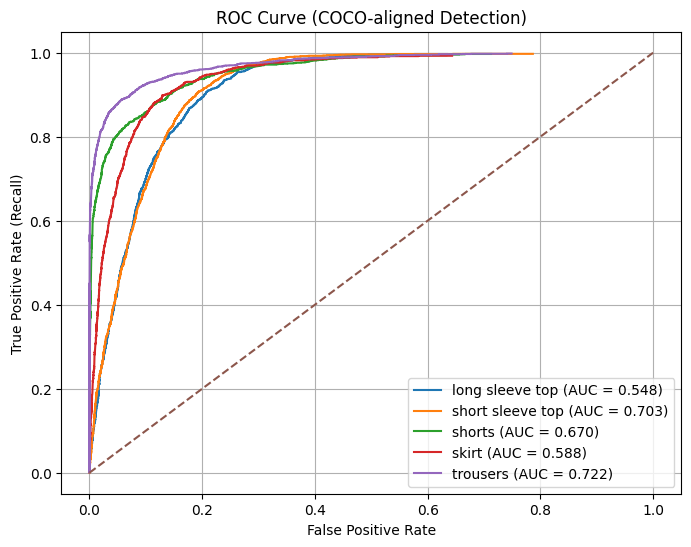

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for cls in roc_curves:
    fpr, tpr = roc_curves[cls]
    auc_val = auc_scores.get(cls, None)

    if len(fpr) < 2:
        continue

    if auc_val is not None:
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc_val:.3f})")
    else:
        plt.plot(fpr, tpr, label=f"{cls}")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (COCO-aligned Detection)")
plt.legend()
plt.grid()

plt.show()

# Segmentation Metrics

In [25]:
import numpy as np

def instances_to_semantic(masks, labels, H, W):
    sem = np.zeros((H, W), dtype=np.int32)
    for mask, lbl in zip(masks, labels):
        m = mask.astype(np.uint8)
        if m.ndim == 3: m = m[0]          # squeeze (1,H,W) → (H,W)
        if m.shape != (H, W):
            m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
        sem[m > 0] = int(lbl)
    return sem

iou_num  = np.zeros(len(mlb.classes_))
iou_den  = np.zeros(len(mlb.classes_))
dice_num = np.zeros(len(mlb.classes_))
dice_den = np.zeros(len(mlb.classes_))

for out, tgt in raw_results:
    # Squeeze channel dim: Mask R-CNN outputs (N,1,H,W) not (N,H,W)
    pred_raw = out["masks"]
    if pred_raw.ndim == 4: pred_raw = pred_raw[:, 0, :, :]
    pred_bin    = (pred_raw > 0.5).astype(np.uint8)
    pred_labels = out["labels"]

    gt_raw = tgt["masks"]
    if gt_raw.ndim == 4: gt_raw = gt_raw[:, 0, :, :]
    gt_bin    = (gt_raw > 0).astype(np.uint8)
    gt_labels = tgt["labels"]

    if len(gt_bin) == 0: continue
    H, W = int(gt_bin[0].shape[-2]), int(gt_bin[0].shape[-1])

    gt_sem   = instances_to_semantic(gt_bin,   gt_labels,   H, W)
    pred_sem = instances_to_semantic(pred_bin, pred_labels, H, W)

    for ci, cls_name in enumerate(mlb.classes_):
        cls_id  = class_to_idx[cls_name]
        gt_px   = (gt_sem   == cls_id)
        pred_px = (pred_sem == cls_id)
        tp = np.logical_and(gt_px,   pred_px).sum()
        fp = np.logical_and(pred_px, ~gt_px).sum()
        fn = np.logical_and(~pred_px, gt_px).sum()
        iou_num[ci]  += tp;  iou_den[ci]  += tp + fp + fn
        dice_num[ci] += 2*tp; dice_den[ci] += 2*tp + fp + fn

iou_per_class  = np.where(iou_den  > 0, iou_num  / iou_den,  0.0)
dice_per_class = np.where(dice_den > 0, dice_num / dice_den, 0.0)

print(f"{'Class':<22} {'IoU':>8} {'Dice':>8}")
print("-" * 40)
for cls_name, iou, dice in zip(mlb.classes_, iou_per_class, dice_per_class):
    print(f"{cls_name:<22} {iou:>8.4f} {dice:>8.4f}")
print("=" * 40)
print(f"{'Macro avg':<22} {iou_per_class.mean():>8.4f} {dice_per_class.mean():>8.4f}")
print(f"\nmIoU  = {iou_per_class.mean():.4f}")
print(f"mDice = {dice_per_class.mean():.4f}")


Class                       IoU     Dice
----------------------------------------
long sleeve top          0.1110   0.1998
short sleeve top         0.2346   0.3800
shorts                   0.0962   0.1756
skirt                    0.0780   0.1446
trousers                 0.1868   0.3147
Macro avg                0.1413   0.2429

mIoU  = 0.1413
mDice = 0.2429
